========== PLAY TENNIS DATASET ==========
     Outlook Temperature Humidity    Wind Target
0      sunny         hot     high    weak     no
1      sunny         hot     high  strong     no
2   overcast         hot     high    weak    yes
3       rain        mild     high    weak    yes
4       rain        cool   normal    weak    yes
5       rain        cool   normal  strong     no
6   overcast        cool   normal  strong    yes
7      sunny        mild     high    weak     no
8      sunny        cool   normal    weak    yes
9       rain        mild   normal    weak    yes
10     sunny        mild   normal  strong    yes
11  overcast        mild     high  strong    yes
12  overcast         hot   normal    weak    yes
13      rain        mild     high  strong     no

========== ENCODED DATA ==========
    Outlook_overcast  Outlook_rain  Outlook_sunny  Temperature_cool  \
0              False         False           True             False   
1              False         False           

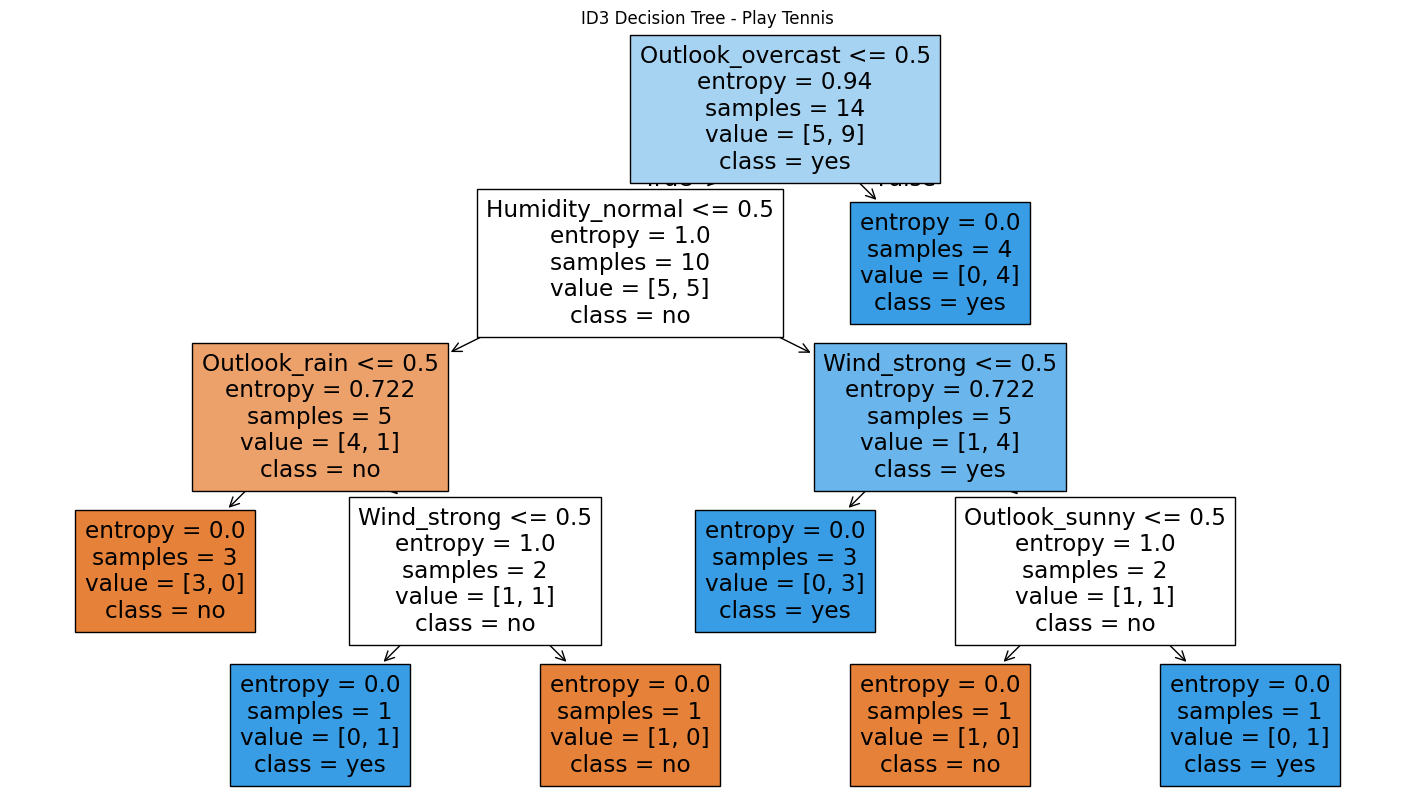


========== NEW SAMPLE ==========
  Outlook Temperature Humidity    Wind
0   sunny        cool     high  strong

========== FINAL RESULT ==========
Outlook     : sunny
Temperature : cool
Humidity    : high
Wind        : strong
Prediction  : NO

ID3 successfully classified the new sample!


In [ ]:
# ============================================================
# ID3 DECISION TREE - PLAY TENNIS
# Dataset + Program in ONE CODE
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

# ------------------------------------------------------------
# 1. CREATE THE PLAY TENNIS DATASET
# ------------------------------------------------------------

data = {
    "Outlook": [
        "sunny", "sunny", "overcast", "rain",
        "rain", "rain", "overcast", "sunny",
        "sunny", "rain", "sunny", "overcast",
        "overcast", "rain"
    ],

    "Temperature": [
        "hot", "hot", "hot", "mild",
        "cool", "cool", "cool", "mild",
        "cool", "mild", "mild", "mild",
        "hot", "mild"
    ],

    "Humidity": [
        "high", "high", "high", "high",
        "normal", "normal", "normal", "high",
        "normal", "normal", "normal", "high",
        "normal", "high"
    ],

    "Wind": [
        "weak", "strong", "weak", "weak",
        "weak", "strong", "strong", "weak",
        "weak", "weak", "strong", "strong",
        "weak", "strong"
    ],

    "Target": [
        "no", "no", "yes", "yes",
        "yes", "no", "yes", "no",
        "yes", "yes", "yes", "yes",
        "yes", "no"
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

print("========== PLAY TENNIS DATASET ==========")
print(df)


# ------------------------------------------------------------
# 2. SEPARATE INPUT FEATURES AND TARGET
# ------------------------------------------------------------

X = df.drop("Target", axis=1)
y = df["Target"]


# ------------------------------------------------------------
# 3. CONVERT TEXT DATA INTO NUMERICAL DATA
# ------------------------------------------------------------

X_encoded = pd.get_dummies(X)

print("\n========== ENCODED DATA ==========")
print(X_encoded)


# ------------------------------------------------------------
# 4. CREATE ID3 DECISION TREE
# ------------------------------------------------------------
# ID3 uses Entropy and Information Gain

model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)


# ------------------------------------------------------------
# 5. TRAIN THE MODEL
# ------------------------------------------------------------

model.fit(X_encoded, y)

print("\nID3 Decision Tree trained successfully!")


# ------------------------------------------------------------
# 6. DISPLAY THE DECISION TREE
# ------------------------------------------------------------

plt.figure(figsize=(18, 10))

plot_tree(
    model,
    feature_names=X_encoded.columns,
    class_names=model.classes_,
    filled=True
)

plt.title("ID3 Decision Tree - Play Tennis")
plt.show()


# ------------------------------------------------------------
# 7. CREATE A NEW SAMPLE
# ------------------------------------------------------------

new_sample = pd.DataFrame({
    "Outlook": ["sunny"],
    "Temperature": ["cool"],
    "Humidity": ["high"],
    "Wind": ["strong"]
})

print("\n========== NEW SAMPLE ==========")
print(new_sample)


# ------------------------------------------------------------
# 8. CONVERT NEW SAMPLE
# ------------------------------------------------------------

new_sample_encoded = pd.get_dummies(new_sample)

new_sample_encoded = new_sample_encoded.reindex(
    columns=X_encoded.columns,
    fill_value=0
)


# ------------------------------------------------------------
# 9. PREDICT THE NEW SAMPLE
# ------------------------------------------------------------

prediction = model.predict(new_sample_encoded)


# ------------------------------------------------------------
# 10. FINAL RESULT
# ------------------------------------------------------------

print("\n========== FINAL RESULT ==========")
print("Outlook     :", new_sample["Outlook"][0])
print("Temperature :", new_sample["Temperature"][0])
print("Humidity    :", new_sample["Humidity"][0])
print("Wind        :", new_sample["Wind"][0])
print("Prediction  :", prediction[0].upper())

print("\nID3 successfully classified the new sample!")